In [2]:
import pandas as pd
import numpy as np

# Количество клиентов
n_clients = 1000

# Фиксируем seed для воспроизводимости
np.random.seed(42)

epk_id = np.arange(1, n_clients + 1)
segment_id = np.random.randint(1, 16, size=n_clients)
fact_pos = np.random.randint(1000, 50000, size=n_clients)
pred_pos = fact_pos + np.random.normal(0, 5000, size=n_clients).astype(int)

df = pd.DataFrame({
    "epk_id": epk_id,
    "segment_id": segment_id,
    "fact_pos": fact_pos,
    "pred_pos": pred_pos
})

print(df.head(10))



   epk_id  segment_id  fact_pos  pred_pos
0       1           7     35816     41425
1       2           4     46106     52658
2       3          13     18100     16988
3       4          15     22949     17215
4       5          11      5544      4972
5       6           8     38744     41910
6       7          13     46543     40407
7       8           5     43783     52083
8       9           7     27657     32146
9      10          10     37187     36155


#### Метрики

In [4]:
def _metrics_for_arrays(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Возвращает словарь метрик для пары массивов фактов и предсказаний."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    n = y_true.size
    err = y_pred - y_true
    abs_err = np.abs(err)
    sq_err = err ** 2

    # Базовые ошибки
    bias = np.mean(err) if n else np.nan
    mae = np.mean(abs_err) if n else np.nan
    rmse = np.sqrt(np.mean(sq_err)) if n else np.nan

    # MAPE: игнорируем наблюдения с y_true == 0, чтобы избежать деления на ноль
    mask_nonzero = y_true != 0
    if np.any(mask_nonzero):
        mape = np.mean(np.abs(err[mask_nonzero] / y_true[mask_nonzero])) * 100
    else:
        mape = np.nan

    # R^2
    y_bar = np.mean(y_true) if n else np.nan
    sst = np.sum((y_true - y_bar) ** 2)
    sse = np.sum((y_true - y_pred) ** 2)
    r2 = 1 - sse / sst if sst != 0 else np.nan

    return {
        "count": int(n),
        "fact_mean": float(np.mean(y_true)) if n else np.nan,
        "pred_mean": float(np.mean(y_pred)) if n else np.nan,
        "bias": float(bias),
        "mae": float(mae),
        "rmse": float(rmse),
        "mape_%": float(mape),
        "r2": float(r2),
    }

def compute_metrics_by_segment(data: pd.DataFrame, group_col: str = "segment_id") -> pd.DataFrame:
    """Считает метрики по группам и добавляет строку 'ALL' для всей выборки."""
    groups = []
    for key, part in data.groupby(group_col):
        groups.append(
            (key, _metrics_for_arrays(part["fact_pos"].values, part["pred_pos"].values))
        )
    # Вся выборка
    overall = _metrics_for_arrays(data["fact_pos"].values, data["pred_pos"].values)
    # Соберём финальный DataFrame
    seg_df = pd.DataFrame(
        [{"segment_id": key, **vals} for key, vals in groups]
    ).sort_values("segment_id").reset_index(drop=True)
    overall_row = pd.DataFrame([{ "segment_id": "ALL", **overall }])
    result = pd.concat([seg_df, overall_row], ignore_index=True)
    # Удобное округление
    result["fact_mean"] = result["fact_mean"].round(2)
    result["pred_mean"] = result["pred_mean"].round(2)
    result["bias"] = result["bias"].round(2)
    result["mae"] = result["mae"].round(2)
    result["rmse"] = result["rmse"].round(2)
    result["mape_%"] = result["mape_%"].round(2)
    result["r2"] = result["r2"].round(4)
    return result

metrics_by_segment = compute_metrics_by_segment(df, "segment_id")

#### Графики

In [5]:
metrics_by_segment

,segment_id,count,fact_mean,pred_mean,bias,mae,rmse,mape_%,r2
0,1,83,24643.29,25283.78,640.49,4211.65,5201.75,32.33,0.8580
1,2,52,24506.88,23367.44,-1139.44,3327.67,4099.06,34.00,0.9279
2,3,75,25521.91,26014.75,492.84,4299.32,5206.04,30.06,0.8733
3,4,62,22156.52,21363.27,-793.24,3768.11,4454.09,46.73,0.9165
4,5,76,22688.82,22490.49,-198.33,3836.62,4670.67,34.29,0.8701
5,6,57,26276.75,26478.35,201.60,4236.79,5459.52,29.54,0.8653
6,7,69,23411.13,23596.45,185.32,3742.19,4841.85,29.85,0.8776
7,8,61,26719.46,27204.61,485.15,4327.21,5416.64,37.19,0.8760
8,9,65,25633.05,24966.57,-666.48,3362.42,4236.07,20.02,0.9013
9,10,74,27107.47,27466.16,358.69,3726.28,4754.84,24.63,0.8779


##### Scatter факт - прогноз

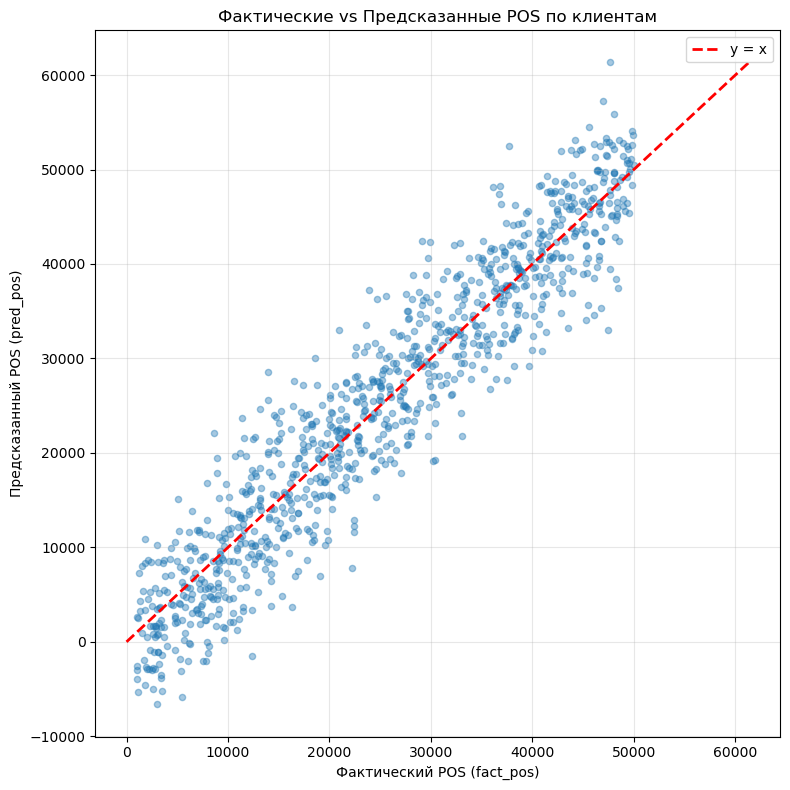

In [7]:
import matplotlib.pyplot as plt

# Scatter plot: fact_pos vs pred_pos
plt.figure(figsize=(8, 8))
plt.scatter(df["fact_pos"], df["pred_pos"], alpha=0.4, s=20)
max_val = max(df["fact_pos"].max(), df["pred_pos"].max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=2, label="y = x")

plt.title("Фактические vs Предсказанные POS по клиентам")
plt.xlabel("Фактический POS (fact_pos)")
plt.ylabel("Предсказанный POS (pred_pos)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

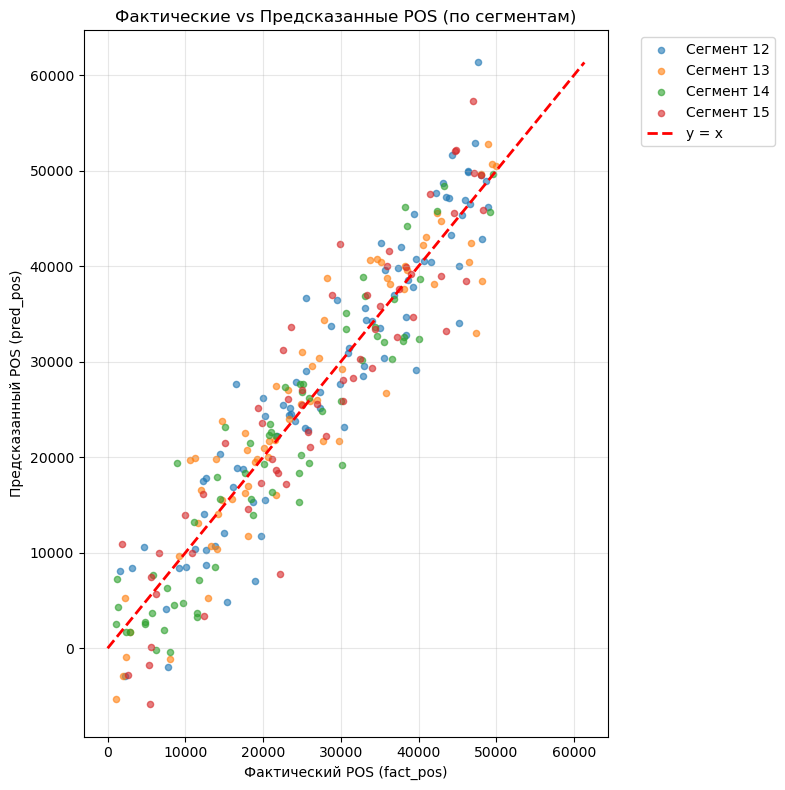

In [30]:
# Список сегментов, которые не хотим показывать
exclude_segments = [1,2,3,4,5,6,7,8,9,10,11]   # ← сюда пиши номера сегментов, которые нужно скрыть

plt.figure(figsize=(8, 8))

# Рисуем scatter по сегментам
for seg, part in df.groupby("segment_id"):
    if seg in exclude_segments:
        continue
    plt.scatter(part["fact_pos"], part["pred_pos"], s=20, alpha=0.6, label=f"Сегмент {seg}")

# Линия y=x
max_val = max(df["fact_pos"].max(), df["pred_pos"].max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=2, label="y = x")

plt.title("Фактические vs Предсказанные POS (по сегментам)")
plt.xlabel("Фактический POS (fact_pos)")
plt.ylabel("Предсказанный POS (pred_pos)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # легенда вынесена сбоку
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

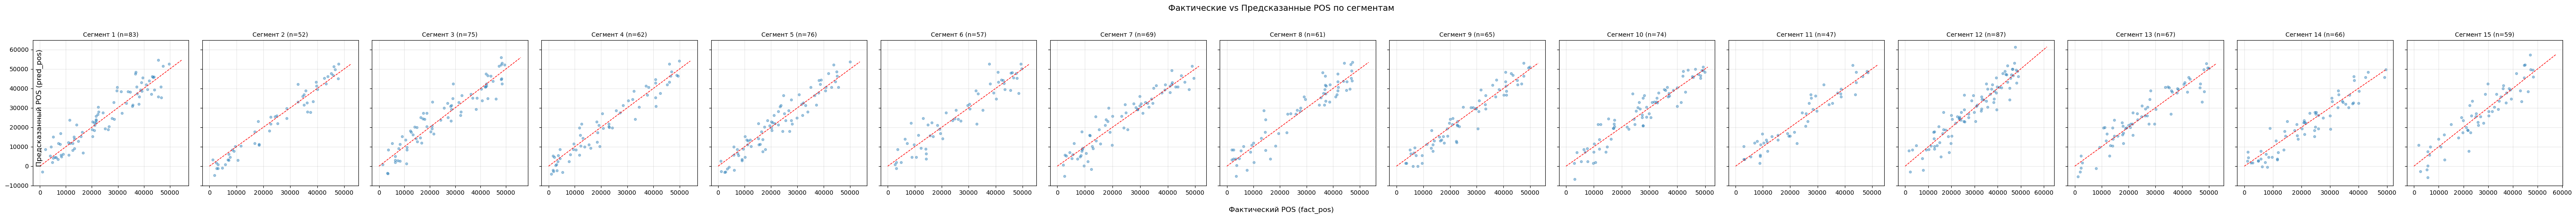

In [21]:
segments = sorted(df["segment_id"].unique())
n_segments = len(segments)

# Колонки = числу сегментов, ряды = 1
ncols = n_segments
nrows = 1

# Ширину фигуры делаем большой (скажем, 4 единицы на сегмент)
fig, axes = plt.subplots(nrows=1, ncols=n_segments, figsize=(4*n_segments, 5), sharey=True)

# Если только один сегмент, axes не будет массивом
if n_segments == 1:
    axes = [axes]

for i, seg in enumerate(segments):
    part = df[df["segment_id"] == seg]
    axes[i].scatter(part["fact_pos"], part["pred_pos"], alpha=0.4, s=15)
    max_val = max(part["fact_pos"].max(), part["pred_pos"].max())
    axes[i].plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=1)
    
    axes[i].set_title(f"Сегмент {seg} (n={len(part)})", fontsize=10)
    axes[i].grid(alpha=0.3)

fig.suptitle("Фактические vs Предсказанные POS по сегментам", fontsize=14)
fig.supxlabel("Фактический POS (fact_pos)")
fig.supylabel("Предсказанный POS (pred_pos)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

##### Scatter ошибки

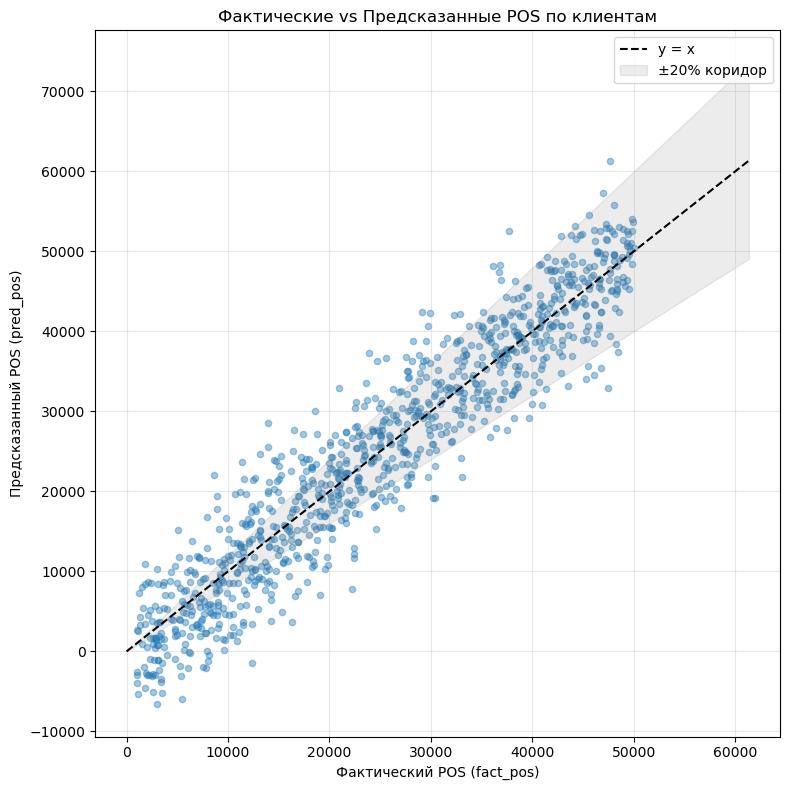

In [24]:
plt.figure(figsize=(8, 8))

# Scatter
plt.scatter(df["fact_pos"], df["pred_pos"], alpha=0.4, s=20)

# Диагональ y=x
max_val = max(df["fact_pos"].max(), df["pred_pos"].max())
plt.plot([0, max_val], [0, max_val], color="black", linestyle="--", linewidth=1.5, label="y = x")

# Полупрозрачный коридор ±20%
x_vals = np.linspace(0, max_val, 200)
plt.fill_between(x_vals, 0.8*x_vals, 1.2*x_vals, color="gray", alpha=0.15, label="±20% коридор")

plt.title("Фактические vs Предсказанные POS по клиентам")
plt.xlabel("Фактический POS (fact_pos)")
plt.ylabel("Предсказанный POS (pred_pos)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

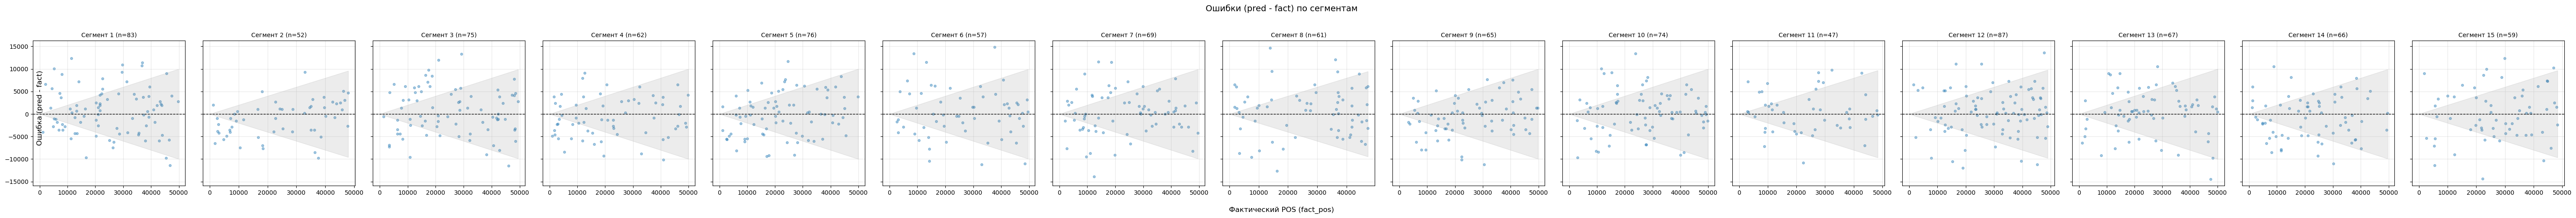

In [22]:
segments = sorted(df["segment_id"].unique())
n_segments = len(segments)

fig, axes = plt.subplots(1, n_segments, figsize=(4*n_segments, 5), sharey=True)

if n_segments == 1:
    axes = [axes]

for i, seg in enumerate(segments):
    part = df[df["segment_id"] == seg]
    errors = part["pred_pos"] - part["fact_pos"]
    
    # Scatter ошибок
    axes[i].scatter(part["fact_pos"], errors, alpha=0.4, s=15)
    
    # Линия 0 (нет ошибки)
    axes[i].axhline(0, color="k", linestyle="--", linewidth=1)
    
    # Коридор ±20%
    x_vals = np.linspace(0, part["fact_pos"].max(), 200)
    axes[i].fill_between(
        x_vals, -0.2*x_vals, 0.2*x_vals,
        color="gray", alpha=0.15, label="±20% коридор"
    )
    
    axes[i].set_title(f"Сегмент {seg} (n={len(part)})", fontsize=10)
    axes[i].grid(alpha=0.3)

fig.suptitle("Ошибки (pred - fact) по сегментам", fontsize=14)
fig.supxlabel("Фактический POS (fact_pos)")
fig.supylabel("Ошибка (pred - fact)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [26]:
from scipy.stats import kruskal

# sMAPE функция
def smape(y_true, y_pred):
    return 2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)) * 100

# Считаем sMAPE для каждого клиента
df["sMAPE"] = smape(df["fact_pos"], df["pred_pos"])

# Kruskal-Wallis тест по сегментам
groups = [group["sMAPE"].values for _, group in df.groupby("segment_id")]
stat, p_value = kruskal(*groups)

# Медианные ошибки по сегментам
median_errors = df.groupby("segment_id")["sMAPE"].median().reset_index().rename(columns={"sMAPE": "median_sMAPE"})

(stat, p_value)

(17.208547622407423, 0.2452346159281536)

In [ ]:
###

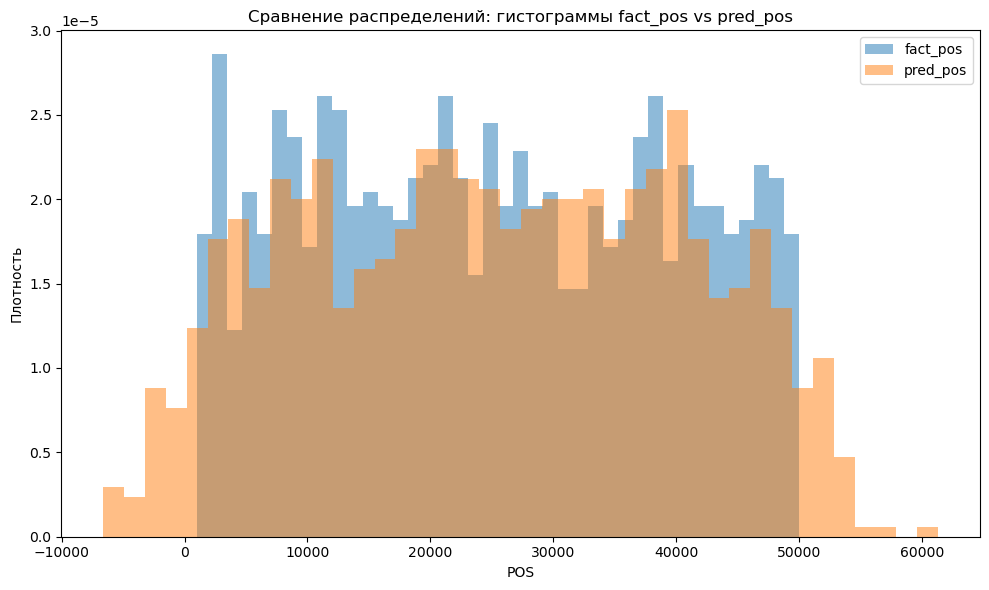

In [10]:
plt.figure(figsize=(10, 6))
bins = 40
plt.hist(df["fact_pos"], bins=bins, alpha=0.5, density=True, label="fact_pos")
plt.hist(df["pred_pos"], bins=bins, alpha=0.5, density=True, label="pred_pos")
plt.title("Сравнение распределений: гистограммы fact_pos vs pred_pos")
plt.xlabel("POS")
plt.ylabel("Плотность")
plt.legend()
plt.tight_layout()
plt.show()

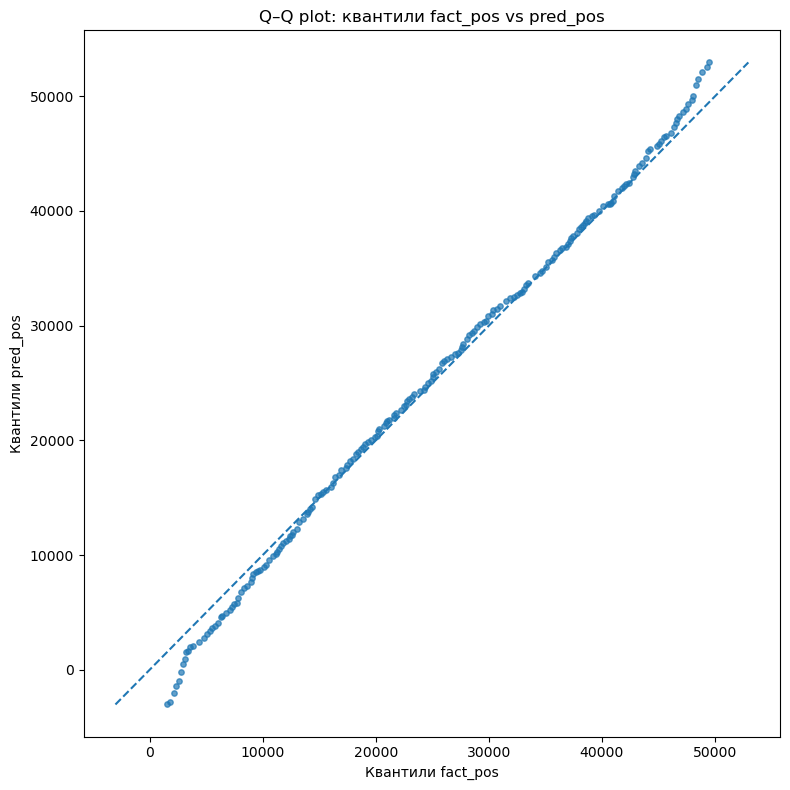

In [12]:
plt.figure(figsize=(8, 8))
q = np.linspace(0.01, 0.99, 200)
fact_q = np.quantile(df["fact_pos"].values, q)
pred_q = np.quantile(df["pred_pos"].values, q)
plt.scatter(fact_q, pred_q, s=15, alpha=0.7)
# Линия y=x для ориентира
mn = min(fact_q.min(), pred_q.min())
mx = max(fact_q.max(), pred_q.max())
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1.5)
plt.title("Q–Q plot: квантили fact_pos vs pred_pos")
plt.xlabel("Квантили fact_pos")
plt.ylabel("Квантили pred_pos")
plt.tight_layout()
plt.show()

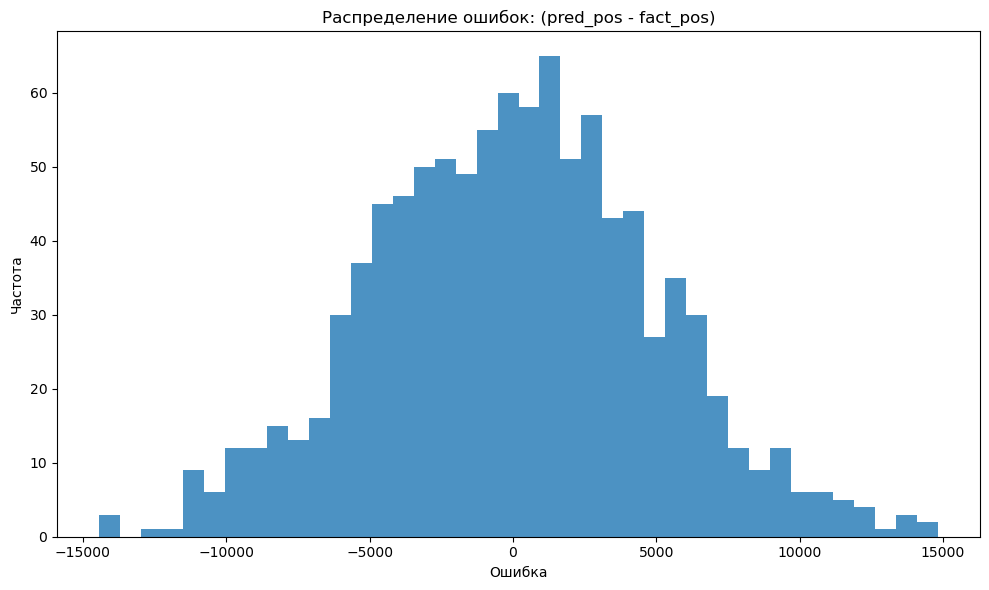

In [13]:
plt.figure(figsize=(10, 6))
errors = df["pred_pos"].values - df["fact_pos"].values
plt.hist(errors, bins=40, alpha=0.8)
plt.title("Распределение ошибок: (pred_pos - fact_pos)")
plt.xlabel("Ошибка")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()


In [ ]:
# Если нужно выгрузить в файл:
df.to_csv("pos_data_august.csv", index=False)